In [1]:
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

In [2]:
from astropy.cosmology import LambdaCDM
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
import numpy as np
from astroML.linear_model import PolynomialRegression

In [12]:
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.gaussian_process import GaussianProcessRegressor

kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) #lets try whit this

gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu ** 2) #typical alpha used

gp.fit(z_sample[:, None], mu_sample)
mu_fit, sigma = gp.predict(z[:, None], return_std=True)

#hacemos la regresion suando ese kernel y considerando el error de mis datos como sigma 2, hac sentido, digo bueno haz el fit y devuleme el mu fit y sus errores sigma

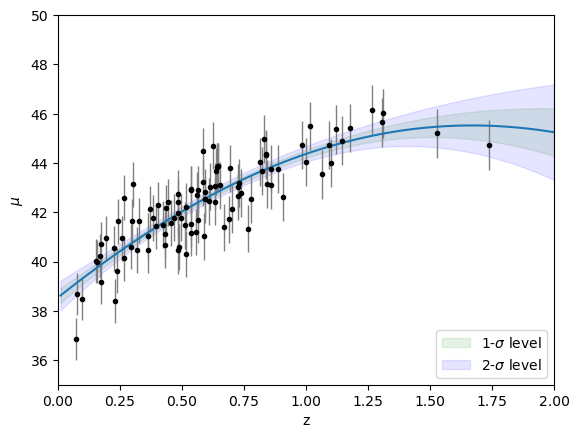

In [13]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

plt.plot(z, mu_fit)

plt.fill_between(z, mu_fit - sigma, mu_fit + sigma,alpha=0.1, color='g', label='1-$\sigma$ level')

plt.fill_between(z, mu_fit - 2* sigma, mu_fit + 2* sigma,alpha=0.1, color='b', label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

#y aqui nada mas y nada menos los grafico
#aqui debes ahora hacer CV para asi tener los mejores parametros, epro qeu carajos se debe buscar de minimizar en el CV? auit

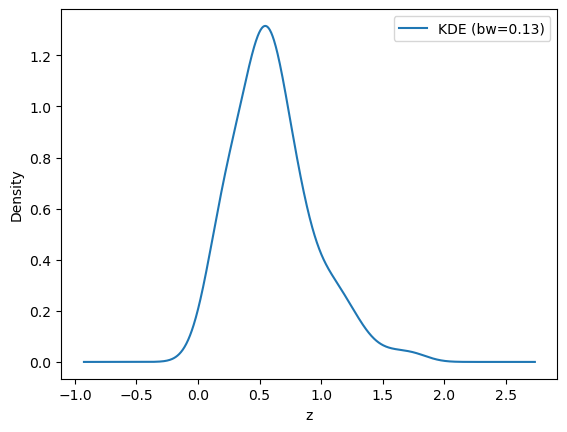

In [14]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

z_vals = np.array(z_sample).reshape(-1, 1)
bandwidths = np.logspace(-2, 0.5, 30)
params = {'bandwidth': bandwidths}
grid = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=5)
grid.fit(z_vals)

kde = grid.best_estimator_
best_bw = grid.best_params_['bandwidth']

z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)

plt.plot(z_plot[:, 0], dens, label=f'KDE (bw={best_bw:.2f})')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()
plt.show()

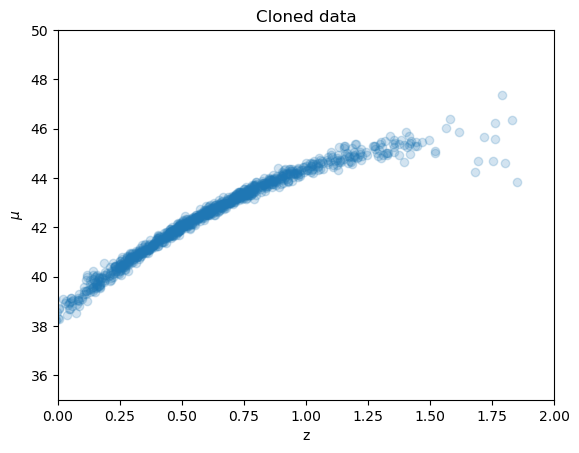

In [15]:
N = 1000
new_z_samples = kde.sample(N)

mu_gpr=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp.predict([[z]], return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))
    
plt.scatter(new_z_samples,mu_gpr,alpha=0.2)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.title("Cloned data");

#aca tiene sentido, porque creas data dada la predicicon que tienes, mira que los putnos se reflejna de acuerdo con los sigma 1 y 2 que tienen.

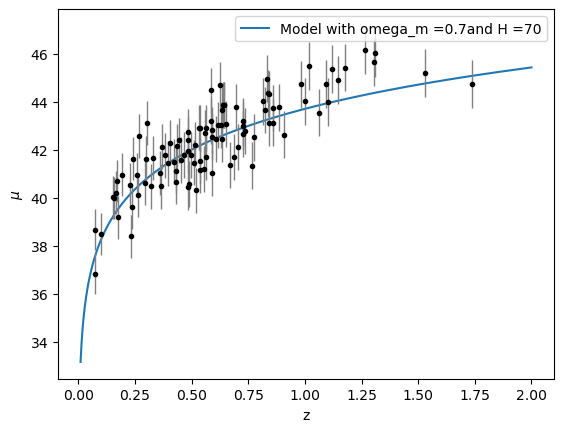

In [80]:
#lets do a parametric fit 
#this is the model, depending on two parameters
from scipy.integrate import quad

c = 299792.458  # en km/s
z = np.linspace(0.01, 2, 1000)

def mu_theory(z, omega_m, H):
    omega_lambda = 1.0 - omega_m

    def integrand(zp):
        return 1.0 / np.sqrt(omega_m * (1 + zp)**3 + omega_lambda)

    def mu_single(z_val):
        integral, _ = quad(integrand, 0, z_val)
        d_L = (c / H) * (1 + z_val) * integral * 1e6 
        mu = 5 * np.log10(d_L / 10.0)
        return mu

    if np.iterable(z):
        return np.array([mu_single(zi) for zi in z])
    else:
        return mu_single(z)

omega = 0.7
H = 70
model=mu_theory(z, omega, H)
plt.plot(z,model, label='Model with omega_m =' + str(omega) + 'and H =' + str(H))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel('z')
plt.ylabel("$\mu$")
plt.legend();
    

In [71]:
#now lets define prior, likehood and posterior

omega_min,omega_max = 0 , 0.8
Hmin,Hmax=50,90
theta_quick= 0.5 , 70

def log_likelihood(theta):
    omega_m, H = theta
    mu_model = mu_theory(z_sample, omega_m, H)
    if np.any(np.isnan(mu_model)):
        return -np.inf
    return -0.5 * np.sum(((mu_sample - mu_model) / dmu) ** 2)
    
def logprior(theta):
    omega_m, H =theta 
    if omega_min < omega_m < omega_max and Hmin < H < Hmax:
        return -0 #the otehrs prios are constant.
    return -np.inf #0 prob

def LogPosterior(theta):
    return log_likelihood(theta) + logprior(theta)


In [76]:
#we run MCMC

import emcee
import scipy.stats

ndim = 2  # number of parameters in the model
nwalkers = 4  # number of MCMC walkers
burn = 100  # "burn-in" period to let chains stabilize
nsteps = 5000  # number of MCMC steps to take **for each walker**

# initialize theta 
starting_guesses = theta_quick + 1e-2 * np.random.random((nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(starting_guesses, nsteps)
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)
emcee_acep = sampler.acceptance_fraction

C:\Users\kevin\AppData\Local\Temp\ipykernel_1964\3854461613.py:12: RuntimeWarning: invalid value encountered in sqrt
  return 1.0 / np.sqrt(omega_m * (1 + zp)**3 + omega_lambda)
C:\Users\kevin\AppData\Local\Temp\ipykernel_1964\3854461613.py:15: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(integrand, 0, z_val)


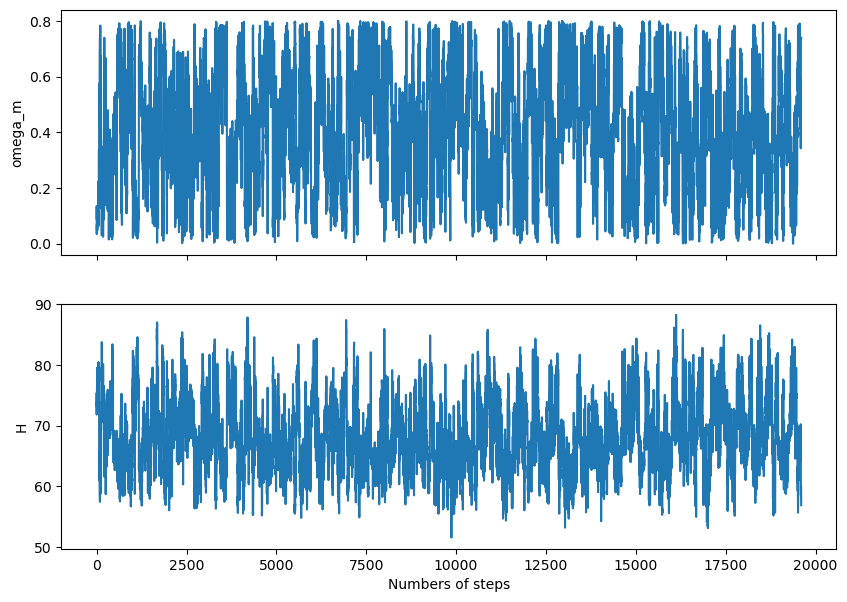

In [77]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
labels = ["omega_m","H"]
N=np.arange(len(emcee_trace[:,1]))
for i in range(ndim):
    ax=axes[i]
    ax.plot(N,emcee_trace[:,i])
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("Numbers of steps");

(384, 2)


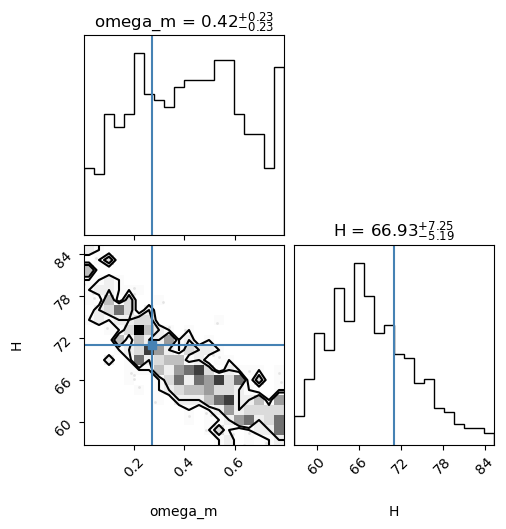

In [83]:
tau = sampler.get_autocorr_time()
thin = int(max(tau))
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)
print(emcee_trace.shape)

import corner

fig = corner.corner(emcee_trace, labels=labels, levels=[0.68,0.95], show_titles=True, truths=[0.27,71]);

In [84]:
for i, l in enumerate(labels):
    low, med, up = np.percentile(emcee_trace[:, i], [5, 50, 95])
    print(f"{l} = {med:.5f} +{(up - med):.5f} -{(med - low):.5f}")

#The ones i got are, and they are correlated since the distribution is inclined

omega_m = 0.41523 +0.34989 -0.33336
H = 66.93365 +11.91362 -7.49708


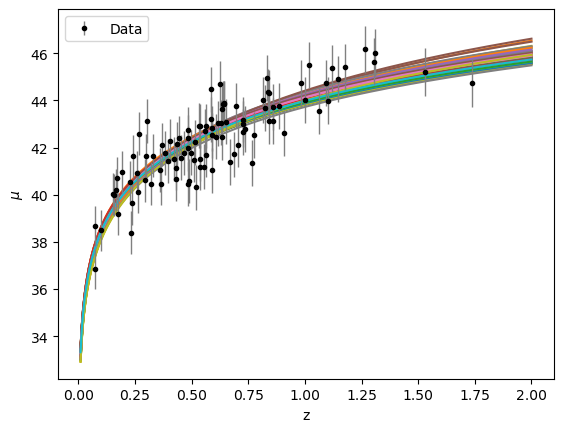

In [89]:
#lets see how it fits
chosen_random=emcee_trace[np.random.choice(len(emcee_trace),size=100)]

for parameters in chosen_random:
    x=mu_theory(z, parameters[0], parameters[1])
    plt.plot(z,x)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Data')
plt.xlabel('z')
plt.ylabel("$\mu$")
plt.legend();

In [90]:
#Model selection stuff 
#considering that now is a model with only one variable , becouse there is not dark energy so:

def mu_theory(z, H):
    omega_m= 1.0
    omega_lambda = 1.0 - omega_m

    def integrand(zp):
        return 1.0 / np.sqrt(omega_m * (1 + zp)**3 + omega_lambda)

    def mu_single(z_val):
        integral, _ = quad(integrand, 0, z_val)
        d_L = (c / H) * (1 + z_val) * integral * 1e6 
        mu = 5 * np.log10(d_L / 10.0)
        return mu

    if np.iterable(z):
        return np.array([mu_single(zi) for zi in z])
    else:
        return mu_single(z)

Hmin,Hmax=30,90
H_quick = 60

def log_likelihood(H):
    mu_model = mu_theory(z_sample, H)
    if np.any(np.isnan(mu_model)):
        return -np.inf
    return -0.5 * np.sum(((mu_sample - mu_model) / dmu) ** 2)
    
def logprior(H):
    if Hmin < H < Hmax:
        return -0 #the otehrs prios are constant.
    return -np.inf #0 prob

def LogPosterior(H):
    return log_likelihood(H) + logprior(H)

ndim = 1  # number of parameters in the model
nwalkers = 4  # number of MCMC walkers
burn = 100  # "burn-in" period to let chains stabilize
nsteps = 5000  # number of MCMC steps to take **for each walker**

# initialize theta 
starting_guesses = H_quick + 1e-2 * np.random.random((nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(starting_guesses, nsteps)
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)
emcee_acep = sampler.acceptance_fraction

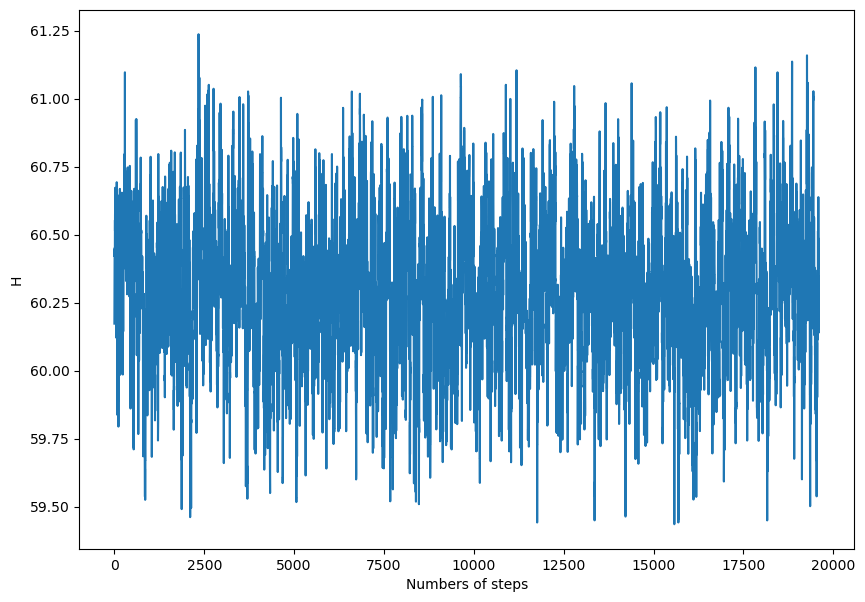

In [102]:
fig, axes = plt.subplots(1, figsize=(10, 7), sharex=True)
labels = 'H'
N=np.arange(len(emcee_trace[:,0]))
axes.plot(N,emcee_trace[:,0])
axes.set_ylabel(labels)

axes.set_xlabel("Numbers of steps");

H = 60.28079 +0.43016 -0.45061


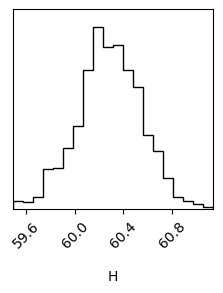

In [105]:
tau = sampler.get_autocorr_time()
thin = int(max(tau))
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)


import corner

fig = corner.corner(emcee_trace, labels=labels, levels=[0.68,0.95]);

for i, l in enumerate(labels):
    low, med, up = np.percentile(emcee_trace[:, i], [5, 50, 95])
    print(f"{l} = {med:.5f} +{(up - med):.5f} -{(med - low):.5f}")

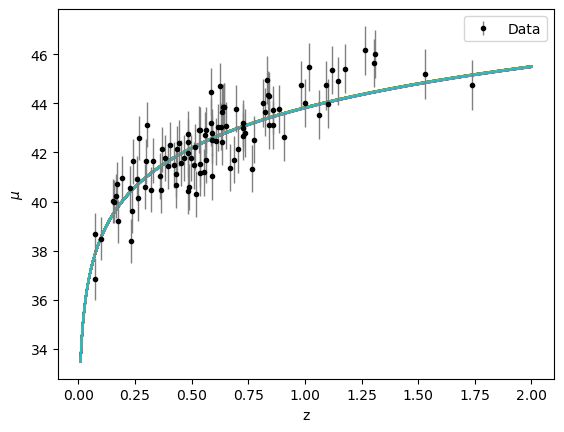

In [106]:
chosen_random=emcee_trace[np.random.choice(len(emcee_trace),size=100)]

for parameters in chosen_random:
    x=mu_theory(z, parameters)
    plt.plot(z,x)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Data')
plt.xlabel('z')
plt.ylabel("$\mu$")
plt.legend(); #how dos this fit looks like for you?? the next thing can be use nested sampling in order to know the evidence and compute the batesian factor.